In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

nvidia = pd.read_excel('Nvidia_Mes_ingles(2024).xlsx', header=3, index_col=0, na_values=['-'])
nvidia = nvidia.dropna()
nvidia.index = pd.to_datetime(nvidia.index, format="%b-%Y")                      
nvidia = nvidia.iloc[:, 0] 
nvidia.name = "NVDA"

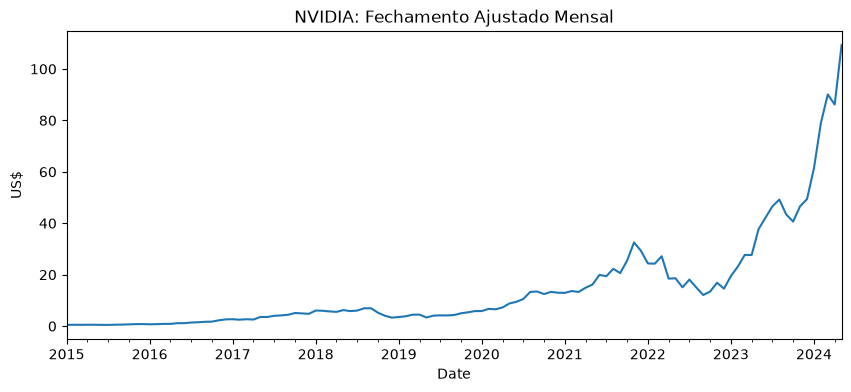

In [2]:
nvidia.plot(figsize=(10,4), title = "NVIDIA: Fechamento Ajustado Mensal")
plt.ylabel("US$")
plt.show()
# A série não é estacionária, visto que sua média não é constante ao longo do tempo, como é notável a partir de 2022.

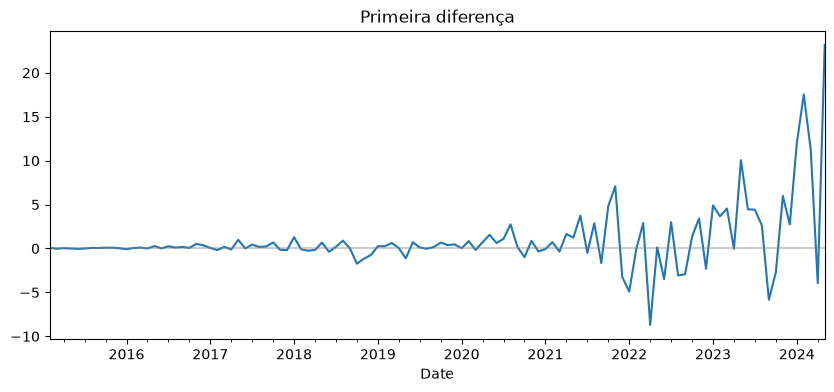

Estat ADF Nvidia: 2.188268668724468
P-valor Nvidia: 0.9988727129371954
Estat ADF primeira diferença: 1.693928497433518
P-valor primeira diferença: 0.9981137088174359


C:\Users\joao1\AppData\Local\Temp\ipykernel_22960\977626935.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_nvidia = adfuller(nvidia.squeeze())
C:\Users\joao1\AppData\Local\Temp\ipykernel_22960\977626935.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_primdiff = adfuller(prim_dif)


In [ ]:
prim_dif = nvidia.diff().dropna()
prim_dif.plot(figsize=(10, 4), title = "Primeira diferença")
plt.axhline(0, color = "gray", alpha = 0.4)
plt.show()

resultado_nvidia = adfuller(nvidia.squeeze())
Adf1 = resultado_nvidia[0]
p_valor1 = resultado_nvidia[1]
print(f"Estat ADF Nvidia: {Adf1}")
print(f"P-valor Nvidia: {p_valor1}")

resultado_primdiff = adfuller(prim_dif)
Adf2 = resultado_primdiff[0]
p_valor2 = resultado_primdiff[1]
print(f"Estat ADF primeira diferença: {Adf2}")
print(f"P-valor primeira diferença: {p_valor2}")

# A primeira e a segunda séries não são estacionárias, visto que o p-valor de ambas é maior que 5%, ou seja, elas não rejeitam a hipótese nula do teste.

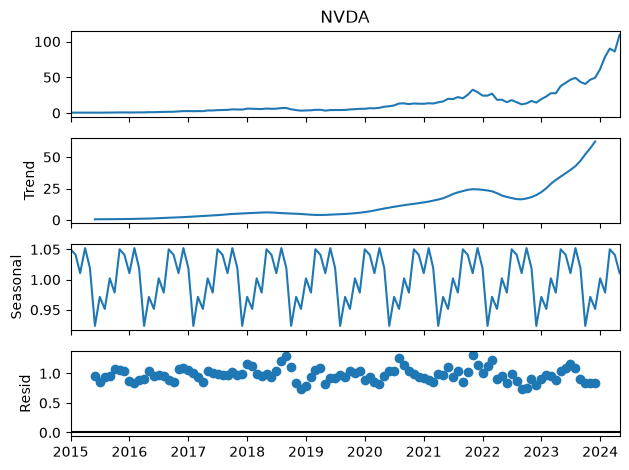

In [4]:
decomposicao = seasonal_decompose(nvidia, model = "multiplicative", period= 10)
decomposicao.plot()
plt.show()
#  Na série, a tendência mostra que a ação cresce lentamente até 2020, quando tem uma leve queda, que depois é recuperada e excedida por uma forte alta a partir de 2023 (devido a forte demanda causada pela IA) ]
# Já a sazonalidade é fraca quando comparada a tendência, visto que seu efeito no preço é de um pouco mais que 5%, enquanto a tendência multiplica o preço em mais de 100x.
# Por fim, os resíduos mostram uma parte importante do histórico da ação, visto que os picos e quedas repentinos não são contemplados na tendência (por ser uma curva suavizada) e constituem parte importante do movimento da ação (em média 13%)

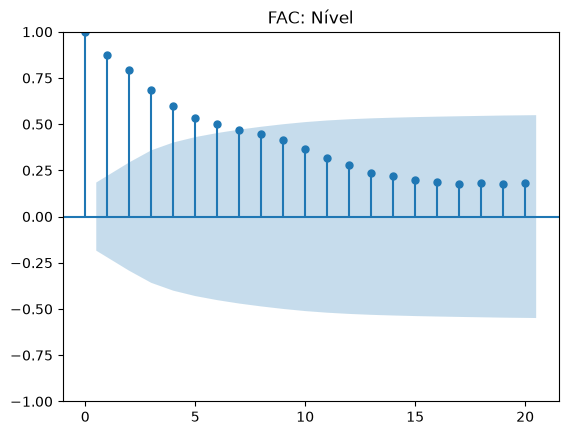

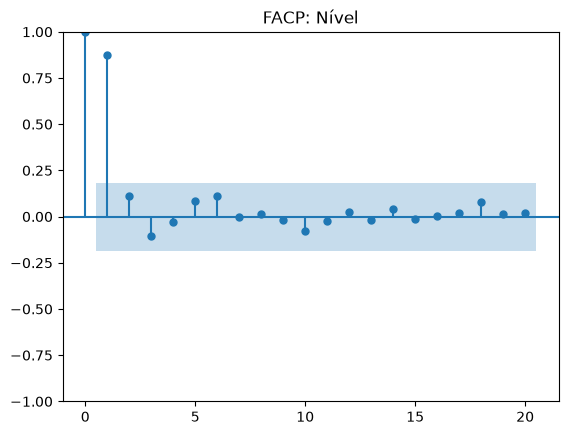

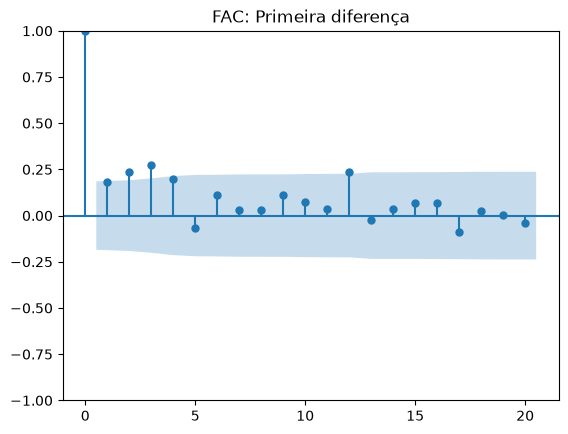

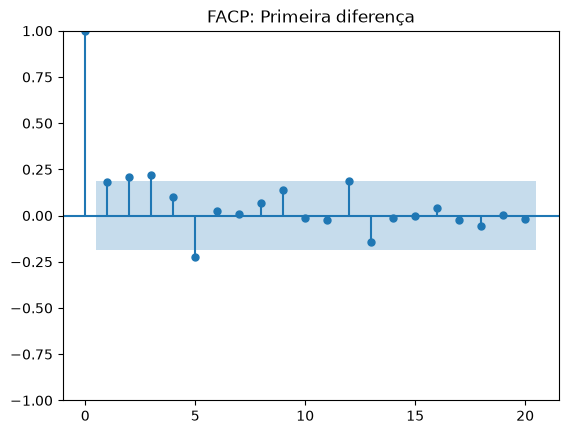

In [5]:
# Em nível
plot_acf(nvidia, lags = 20, title = "FAC: Nível") # Cai lentamente, o que é típico em funções não estacionárias, mostrando que os preços passados influenciam muito o preço presente.
plot_pacf(nvidia, lags = 20, title = "FACP: Nível") # O primeiro lag é grande (próximo de 1), mostrando que o preço do mês t é fortemente influenciado pelo preço em t-1. Para o resto dos lags, todos ficam dentro da faixa, ou seja, meses passados (fora o imediatamente anterior), agregam pouca informação após considerar o mês passado.
# Primeira diferença
plot_acf(prim_dif, lags = 20, title = "FAC: Primeira diferença") # As barras curtas mostram que o passado tem pouquissíma influência nos preços presentes.
plot_pacf(prim_dif, lags = 20, title = "FACP: Primeira diferença") # Novamente, as barras curtas, com algumas superando um pouco a faixa, mostram que não há uma forte influência dos preços passados nos presentes.
plt.show()

# A FAC mostra a relação direta e indireta dos preços anteriores com o preço atual, ou seja, inclui o efeito indireto de meses passados intermediários além do que está sendo comparado imediatamente, por exemplo: quanto t-1 afeta t, quanto t-2 afeta t + quanto t-2 influencia t-1 que influencia t, etc... . 
# Já a FACP mostra a relação direta dos preços anteriores com o preço atual, por exemplo: quanto t-1 afeta t, quanto t-2 afeta t, etc...


c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\joao1\OneDrive\Área de Trab

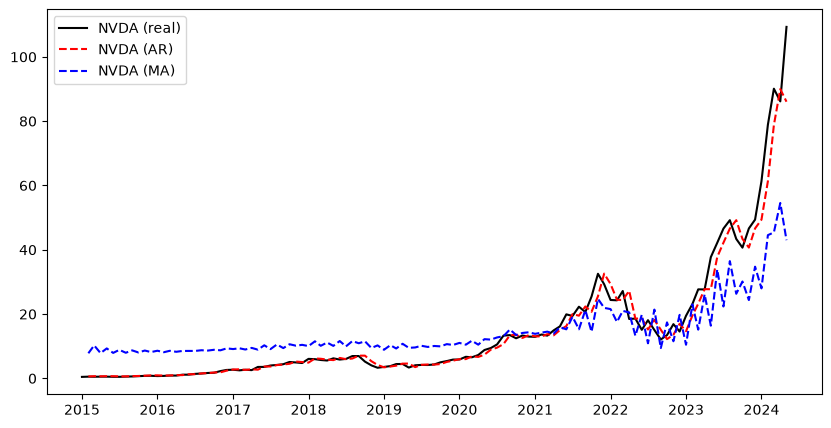

In [6]:
ar = ARIMA(nvidia, order = (1, 0, 0)).fit()
ma = ARIMA(nvidia, order = (0, 0, 1)).fit()
plt.figure(figsize=(10, 5)) 
plt.plot(nvidia, color="black", label="NVDA (real)")
plt.plot(ar.fittedvalues[1:], color = "red", label = "NVDA (AR)", linestyle = "--")
plt.plot(ma.fittedvalues[1:], color = "blue", label = "NVDA (MA)", linestyle = '--')
plt.legend()
plt.show()
# AR estima o preço somando: constante + peso do preço anterior * preço anterior (nesse caso o preço em t-1) + erro em t. Dessa forma, estima o preço presente a partir do preço imediatamente anterior (caso seja AR(1)).
# MA estima o preço somando: constante + peso do erro anterior * erro anterior (nesse caso o erro em t-1) + erro em t. Assim, estima o preço a partir do erro imediatamente anterior (para MA(1))

In [7]:
print(ar.summary())
print(ma.summary())
print("AIC AR:", ar.aic)
print("AIC MA:", ma.aic)
# Pelo AIC, o melhor modelo é AR, visto que AIC de AR = 640 < AIC de MA = 884.
# Os critérios de informação são importantes para penalizar modelos com vários parâmetros e eliminar problemas de overfitting,
# visto que modelos com muitos parâmetros podem se ajustar melhor ao passado simplesmente por serem mais flexíveis, mas possuírem capacidades predictivas piores.

                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                  113
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -317.449
Date:                Tue, 06 Oct 2026   AIC                            640.897
Time:                        18:43:07   BIC                            649.079
Sample:                    01-01-2015   HQIC                           644.217
                         - 05-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.1789     53.323      0.922      0.356     -55.332     153.690
ar.L1          0.9971      0.019     51.285      0.000       0.959       1.035
sigma2        15.4122      1.053     14.643      0.0

c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joao1\OneDrive\Área de Trabalho\Quant\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\joao1\OneDrive\Área de Trab

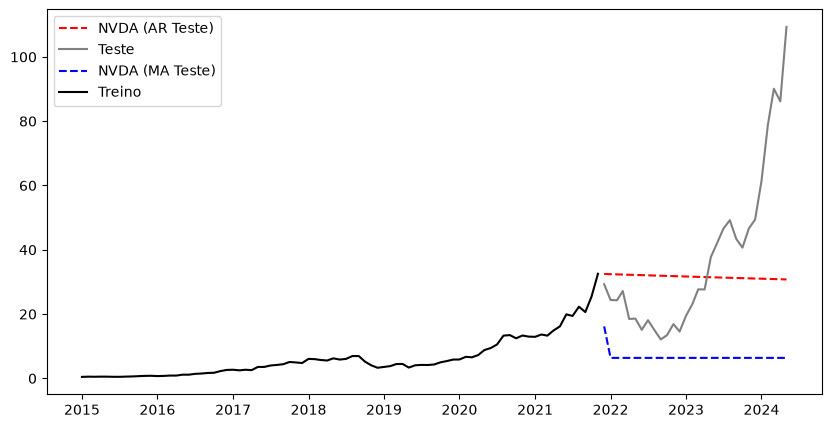

EQM AR(1): 676.3703442289083
EQM MA(1): 1581.4099267731956


In [8]:
treino = nvidia.iloc[:-30]
teste = nvidia.iloc[-30:]

ar_treino = ARIMA(treino, order=(1, 0, 0)).fit()
ma_treino = ARIMA(treino, order=(0, 0, 1)).fit()

ar_teste = ar_treino.forecast(steps=30)
ma_teste = ma_treino.forecast(steps=30)

plt.figure(figsize=(10, 5))
plt.plot(ar_teste, color = "red", label = "NVDA (AR Teste)", linestyle = '--')
plt.plot(teste, color = "grey", label = "Teste")
plt.plot(ma_teste, color = "blue", label = "NVDA (MA Teste)", linestyle = '--')
plt.plot(treino, color = 'black', label = "Treino")
plt.legend()
plt.show()

eqm_ar = print("EQM AR(1):", ((teste -ar_teste)**2).mean())
eqm_ma = print("EQM MA(1):", ((teste - ma_teste)**2).mean())